In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
# --! import Python libraries and KIND framework files -------------------!

import torch
from matplotlib import pyplot as plt

import kind
import utils_plot


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        2
   valid     1000                200        2
    test      500                200        2



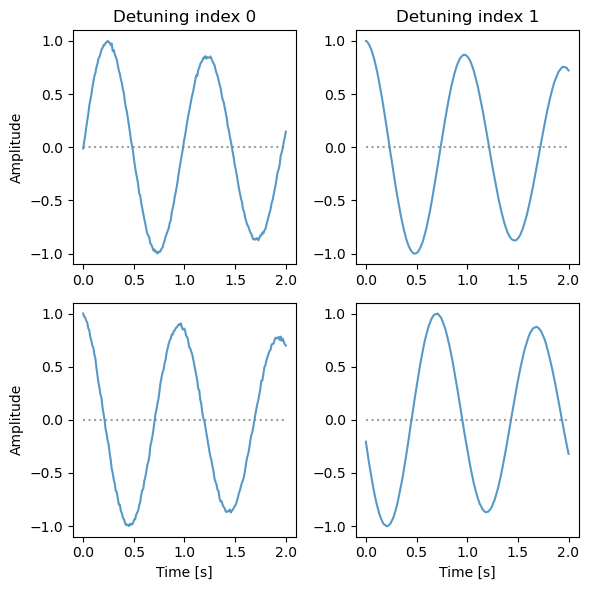

In [3]:
# --!------------------------------------------------------!
# --! display stationary dataset

datadir               = '../../data/baselines/train_sim_stat'
timeseries_ndim       = 2
timeseries_nsample    = 200
timestep              = 0.01

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep)


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        2
   valid     1000                200        2
    test      500                200        2



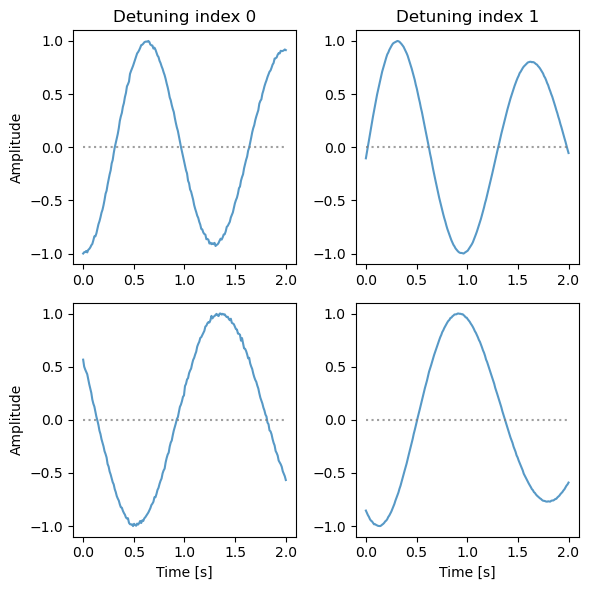

In [4]:
# --!------------------------------------------------------!
# --! display transient dataset

datadir               = '../../data/baselines/train_sim_trans'
timeseries_ndim       = 2
timeseries_nsample    = 200
timestep              = 0.01

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep)

In [5]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 123
torch.manual_seed(seed)

forecast_nsample = 50
lookback_nsample = timeseries_nsample - forecast_nsample

model_cfg = kind.model_config(

    timeseries_ndim    = timeseries_ndim,
    timestep           = timestep,
    lookback_nsample   = lookback_nsample,
    forecast_nsample   = forecast_nsample,

    fun_stat = {
        'data1'  : 1,
        'sin'    : 2,
        'cos'    : 2
    },

    fun_trans = {
        'data1'  : 1,
        'data2'  : 1,
        'data3'  : 1,
        'data4'  : 1,
        'sin'    : 2,
        'cos'    : 2
    },

    param_kernsize = 25,
)

model = kind.model(model_cfg)

In [6]:
# --!--------------------------------------------------------------------------
# --! train all phases in one loop

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : '../../data/baselines/train_sim_stat',
    'transdatadir'          : '../../data/baselines/train_sim_trans',
    'mixdatadir'            : '../../data/baselines/train_sim_mixed',
    'timeseries_nsample'    : timeseries_nsample,
    'train_nfile'           : 3,
    'batsize'               : batsize,
    'nepoch'                : 100,
    'isverbose'             : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-4,
}

loss = []

while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

inf >> fit: entering stationary mean phase
inf >> number of data files for training is 3
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> fit: entering stationary variance phase
inf >> number of data files for training is 3
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> fit: entering transient mean phase
inf >> number of data files for training is 3
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> fit: entering transient variance phase
inf >> number of data files for training is 3
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3


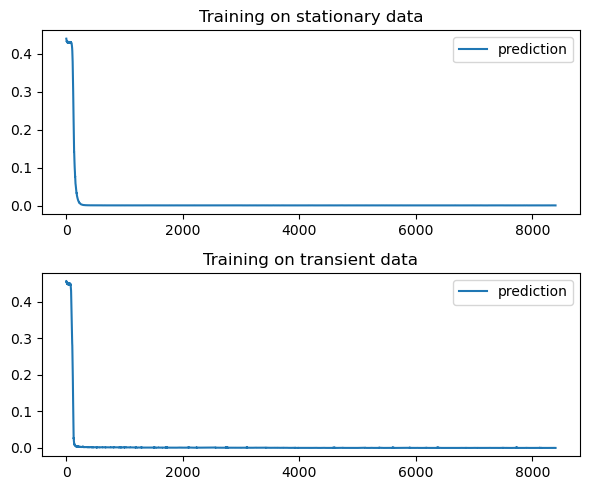

In [7]:
# --!--------------------------------------------------------------------------
# --! plot training statistics

with torch.no_grad():
    loss_stat  = loss[0]
    loss_trans = loss[2]

    plt.figure(figsize=(6, 5))

    plt.subplot(2, 1, 1)
    plt.title('Training on stationary data')
    plt.plot(loss_stat[0], label='prediction')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.title('Training on transient data')
    plt.plot(loss_trans[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [8]:
# --!--------------------------------------------------------------------------
# --! save a trained model

modelsaved = True

if modelsaved:
    torch.save(model, '../../models/baselines/odmd_kind_sim.pt')